# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Desvita Maharani
- **Email:** 111202315298@mhs.dinus.ac.id / cdcc007d6x2681@student.devacademy.id
- **ID Dicoding:** CDCC007D6X2681

## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1:** Bagaimana pengaruh musim, kondisi cuaca, dan status hari kerja/libur terhadap jumlah penyewaan sepeda?
- **Pertanyaan 2:** Pada jam berapa jumlah penyewaan sepeda paling tinggi, dan bagaimana perbedaannya antara hari kerja dan hari libur?

## Import Semua Packages/Library yang Digunakan

In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_theme(style="whitegrid")
plt.style.use("default")

## Data Wrangling

### Gathering Data

In [4]:
day_df = pd.read_csv("day.csv")
hour_df = pd.read_csv("hour.csv")

day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [5]:
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**

- Dataset Bike Sharing terdiri dari dua file utama yaitu **day.csv** dan **hour.csv**.
- Dataset **day.csv** berisi data penyewaan sepeda dalam skala harian, sedangkan **hour.csv** berisi data penyewaan sepeda dalam skala per jam.
- Kedua dataset memiliki beberapa variabel penting seperti musim, kondisi cuaca, suhu, kelembapan, kecepatan angin, serta jumlah total penyewaan sepeda (`cnt`).
- Dataset ini dapat digunakan untuk menganalisis pola penyewaan sepeda berdasarkan faktor waktu dan kondisi lingkungan.

### Assessing Data

In [6]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [7]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [8]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [9]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [10]:
print("Missing value day_df")
print(day_df.isna().sum())

print("\nMissing value hour_df")
print(hour_df.isna().sum())

Missing value day_df
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Missing value hour_df
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [11]:
print("Duplicate day:", day_df.duplicated().sum())
print("Duplicate hour:", hour_df.duplicated().sum())

Duplicate day: 0
Duplicate hour: 0


**Insight:**

- Dataset tidak memiliki missing value maupun data duplikat sehingga dapat langsung digunakan untuk proses analisis.
- Dataset terdiri dari dua bagian yaitu data harian (`day.csv`) dan data per jam (`hour.csv`).
- Variabel seperti `season`, `weathersit`, `weekday`, dan `workingday` masih berupa kode numerik sehingga perlu diubah menjadi label agar lebih mudah dipahami.

### Cleaning Data

In [12]:
day_df["dteday"] = pd.to_datetime(day_df["dteday"])
hour_df["dteday"] = pd.to_datetime(hour_df["dteday"])

In [13]:
season_map = {
1: "Spring",
2: "Summer",
3: "Fall",
4: "Winter"
}

weather_map = {
1: "Clear",
2: "Mist",
3: "Light Snow/Rain",
4: "Heavy Rain/Snow"
}

weekday_map = {
0: "Sunday",
1: "Monday",
2: "Tuesday",
3: "Wednesday",
4: "Thursday",
5: "Friday",
6: "Saturday"
}

workingday_map = {
0: "Holiday",
1: "Working Day"
}

In [14]:
day_df["season_label"] = day_df["season"].map(season_map)
day_df["weather_label"] = day_df["weathersit"].map(weather_map)
day_df["weekday_label"] = day_df["weekday"].map(weekday_map)
day_df["workingday_label"] = day_df["workingday"].map(workingday_map)

hour_df["season_label"] = hour_df["season"].map(season_map)
hour_df["weather_label"] = hour_df["weathersit"].map(weather_map)
hour_df["weekday_label"] = hour_df["weekday"].map(weekday_map)
hour_df["workingday_label"] = hour_df["workingday"].map(workingday_map)

**Insight:**

- Kolom tanggal berhasil diubah menjadi tipe datetime sehingga dapat digunakan untuk analisis berbasis waktu.
- Variabel kategori berhasil dikonversi menjadi label sehingga memudahkan interpretasi dalam visualisasi dan analisis.

## Exploratory Data Analysis (EDA)

### Analisis Musim

In [15]:
season_rental = day_df.groupby("season_label")["cnt"].sum().sort_values(ascending=False)
season_rental

,cnt
season_label,
Fall,1061129
Summer,918589
Winter,841613
Spring,471348


### Analisis Cuaca

In [16]:
weather_rental = day_df.groupby("weather_label")["cnt"].sum().sort_values(ascending=False)
weather_rental

,cnt
weather_label,
Clear,2257952
Mist,996858
Light Snow/Rain,37869


### Analisis Hari Kerja

In [17]:
workingday_rental = day_df.groupby("workingday_label")["cnt"].mean()
workingday_rental

,cnt
workingday_label,
Holiday,4330.168831
Working Day,4584.820000


### Analisis Jam

In [18]:
hour_rental = hour_df.groupby("hr")["cnt"].mean()
hour_rental.head()

,cnt
hr,
0,53.898072
1,33.375691
2,22.869930
3,11.727403
4,6.352941


**Insight:**

Hasil eksplorasi data menunjukkan bahwa jumlah penyewaan sepeda dipengaruhi oleh beberapa faktor lingkungan dan waktu. Musim **Fall** dan **Summer** menunjukkan jumlah penyewaan sepeda yang lebih tinggi dibandingkan musim lainnya. Selain itu, kondisi cuaca yang cerah juga berkorelasi dengan jumlah penyewaan yang lebih tinggi. Analisis awal juga menunjukkan bahwa terdapat variasi jumlah penyewaan sepeda berdasarkan waktu dalam sehari, yang mengindikasikan adanya pola penggunaan sepeda yang berbeda sepanjang hari.

## Visualization & Explanatory Analysis

### Visualisasi Musim

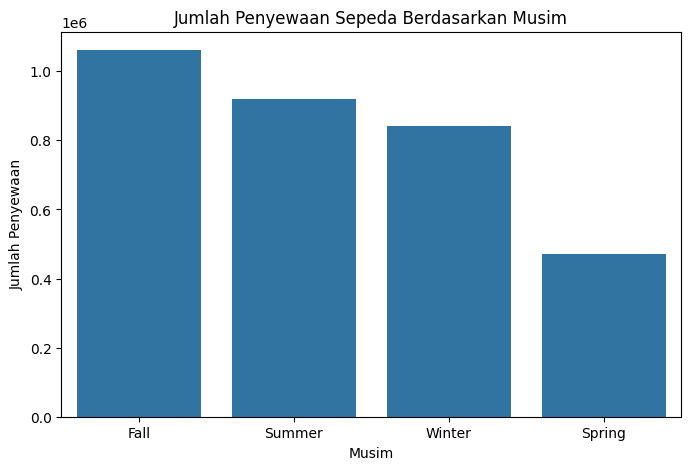

In [19]:
plt.figure(figsize=(8,5))
sns.barplot(x=season_rental.index, y=season_rental.values)

plt.title("Jumlah Penyewaan Sepeda Berdasarkan Musim")
plt.xlabel("Musim")
plt.ylabel("Jumlah Penyewaan")

plt.show()

### Visualisasi Cuaca

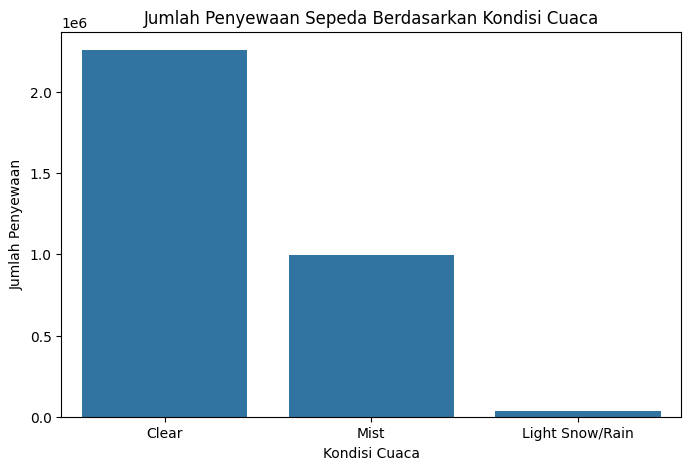

In [20]:
plt.figure(figsize=(8,5))
sns.barplot(x=weather_rental.index, y=weather_rental.values)

plt.title("Jumlah Penyewaan Sepeda Berdasarkan Kondisi Cuaca")
plt.xlabel("Kondisi Cuaca")
plt.ylabel("Jumlah Penyewaan")

plt.show()

### Visualisasi Jam

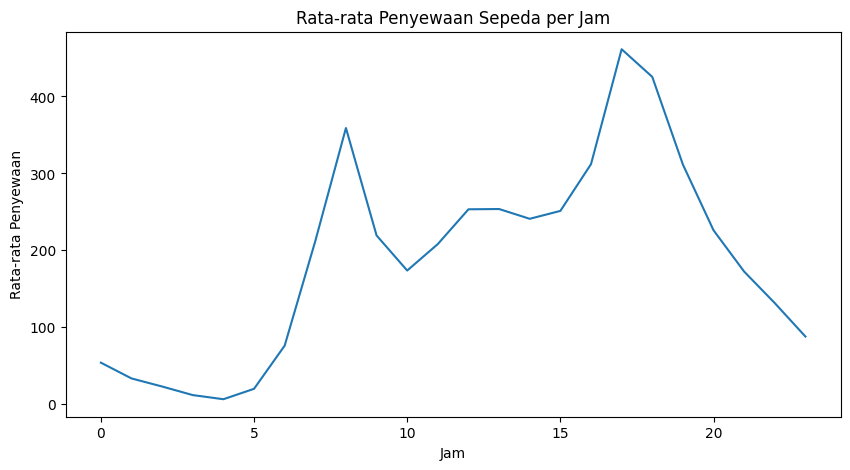

In [21]:
plt.figure(figsize=(10,5))
sns.lineplot(x=hour_rental.index, y=hour_rental.values)

plt.title("Rata-rata Penyewaan Sepeda per Jam")
plt.xlabel("Jam")
plt.ylabel("Rata-rata Penyewaan")

plt.show()

**Insight:**

Visualisasi menunjukkan bahwa jumlah penyewaan sepeda sangat dipengaruhi oleh musim dan kondisi cuaca. Musim **Fall** memiliki jumlah penyewaan sepeda tertinggi, diikuti oleh musim **Summer**, sedangkan musim **Spring** memiliki jumlah penyewaan paling rendah. Hal ini menunjukkan bahwa kondisi cuaca yang lebih nyaman pada musim tertentu mendorong masyarakat untuk lebih sering menggunakan sepeda. Selain itu, kondisi cuaca **Clear** menghasilkan jumlah penyewaan paling tinggi dibandingkan kondisi cuaca lainnya. Dari sisi status hari, rata-rata penyewaan sepeda pada **hari kerja** sedikit lebih tinggi dibandingkan hari libur, yang menunjukkan bahwa sepeda sering digunakan sebagai sarana transportasi untuk aktivitas sehari-hari.

### Perbandingan Hari Kerja vs Hari Libur

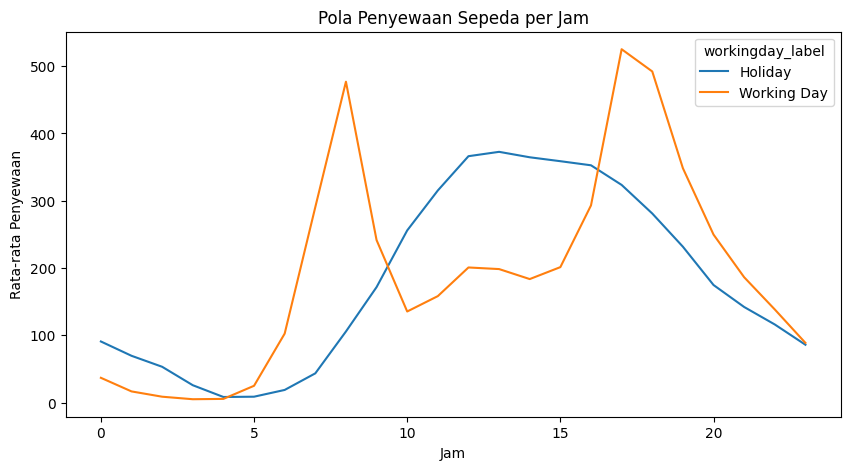

In [22]:
hourly_workingday = hour_df.groupby(["workingday_label","hr"])["cnt"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=hourly_workingday,x="hr",y="cnt",hue="workingday_label")

plt.title("Pola Penyewaan Sepeda per Jam")
plt.xlabel("Jam")
plt.ylabel("Rata-rata Penyewaan")

plt.show()

**Insight:**

Visualisasi pola penyewaan sepeda per jam menunjukkan adanya perbedaan pola antara hari kerja dan hari libur. Pada **hari kerja**, puncak penyewaan sepeda terjadi pada sekitar **jam 08.00** dan **17.00–18.00**, yang kemungkinan berkaitan dengan aktivitas berangkat dan pulang kerja. Sementara itu, pada **hari libur**, jumlah penyewaan sepeda lebih merata sepanjang hari dan cenderung meningkat pada **siang hingga sore hari**, terutama sekitar **jam 12.00–16.00**. Hal ini menunjukkan bahwa pada hari libur sepeda lebih sering digunakan untuk aktivitas rekreasi dibandingkan mobilitas rutin.

## Analisis Lanjutan (Opsional)

### Binning Waktu

In [23]:
def categorize_hour(hour):

    if hour < 6:
        return "Dini Hari"

    elif hour < 10:
        return "Pagi"

    elif hour < 15:
        return "Siang"

    elif hour < 19:
        return "Sore"

    else:
        return "Malam"

In [24]:
hour_df["time_category"] = hour_df["hr"].apply(categorize_hour)

In [25]:
time_category_rental = hour_df.groupby(["workingday_label","time_category"])["cnt"].mean().reset_index()
time_category_rental

,workingday_label,time_category,cnt
0,Holiday,Dini Hari,42.998534
1,Holiday,Malam,150.093043
2,Holiday,Pagi,85.000000
3,Holiday,Siang,334.972294
4,Holiday,Sore,329.088841
5,Working Day,Dini Hari,16.435096
6,Working Day,Malam,202.301205
7,Working Day,Pagi,277.909274
8,Working Day,Siang,175.319517
9,Working Day,Sore,378.024072


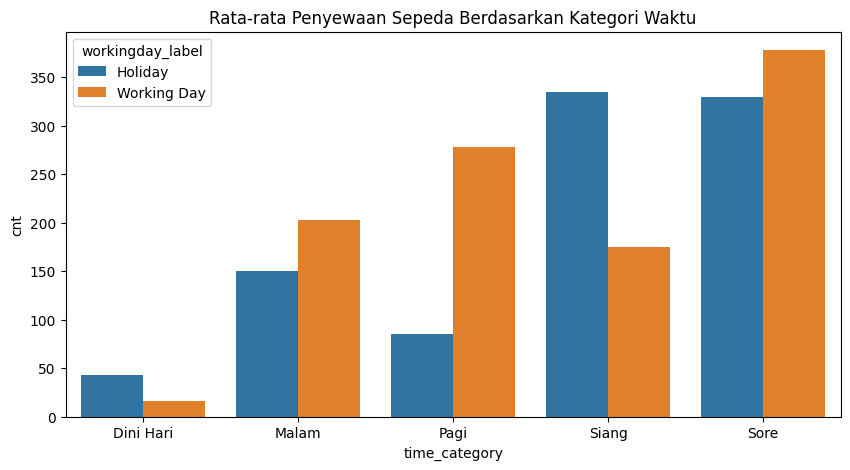

In [26]:
plt.figure(figsize=(10,5))

sns.barplot(
data=time_category_rental,
x="time_category",
y="cnt",
hue="workingday_label"
)

plt.title("Rata-rata Penyewaan Sepeda Berdasarkan Kategori Waktu")

plt.show()

**Insight:**

Dengan mengelompokkan jam ke dalam beberapa kategori waktu seperti dini hari, pagi, siang, sore, dan malam, terlihat bahwa rata-rata penyewaan sepeda paling tinggi terjadi pada kategori waktu **sore hari**, terutama pada hari kerja. Hal ini menunjukkan bahwa sepeda banyak digunakan setelah jam kerja sebagai sarana transportasi pulang atau aktivitas lain setelah bekerja. Pada hari libur, penyewaan sepeda lebih banyak terjadi pada kategori **siang hingga sore**, yang menunjukkan pola penggunaan yang lebih santai dan bersifat rekreatif.

## Conclusion


### Pertanyaan 1
Jumlah penyewaan sepeda dipengaruhi oleh faktor musim, kondisi cuaca, serta status hari kerja atau hari libur. Musim **Fall** menunjukkan total penyewaan tertinggi sedangkan musim **Spring** memiliki jumlah penyewaan terendah. Selain itu kondisi cuaca cerah menghasilkan jumlah penyewaan paling tinggi, sedangkan cuaca buruk menurunkan jumlah penyewaan secara signifikan.

### Pertanyaan 2
Pola penyewaan sepeda menunjukkan perbedaan yang jelas antara hari kerja dan hari libur. Pada hari kerja puncak penyewaan terjadi pada jam **08.00** serta **17.00–18.00**, yang menunjukkan penggunaan sepeda untuk mobilitas kerja. Sementara pada hari libur penyewaan lebih merata dan cenderung meningkat pada **siang hingga sore hari**.

**Insight**
Secara keseluruhan, hasil analisis menunjukkan bahwa faktor waktu, musim, serta kondisi cuaca memiliki pengaruh yang signifikan terhadap pola penggunaan sepeda pada sistem bike sharing.

In [29]:
main_df = hour_df.copy()
main_df.to_csv("main_data.csv", index=False)